In [1]:
from pathlib import Path
import yaml
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import os

In [3]:
# get path to project root directory
project_root = Path.cwd().parents[0]

# build path to yaml config file
config_path = project_root / "configs"/"paths.yaml"

In [4]:
with open(config_path) as f:
    paths = yaml.safe_load(f)
paths

{'data': {'external': 'data/external',
  'raw': 'data/raw',
  'processed': 'data/processed',
  'results': 'results',
  'imagery': 'data/imagery'},
 'outputs': {'dynamic_maps': 'outputs/maps/dynamic',
  'static_maps': 'output/maps/static',
  'figures': 'output/figures',
  'tables': 'outputs/tables'},
 'imagery': {'nakivale_sample': 'data/imagery/nakivale_sample'}}

In [5]:
# Access imagery root directory
imagery_root = project_root / paths["imagery"]["nakivale_sample"]

# sample grid cell
grid_cell_id = 357

# Access grid cell 208 folder
chip_dir = imagery_root / f'{grid_cell_id}'

print(chip_dir)

c:\Users\Zachary\phd_classes\uganda\data\imagery\nakivale_sample\357


In [6]:
# build paths to vector data
vector_root = project_root/paths['data']['processed']

# build path to roads
roads_path = vector_root/'nakivale_osm_roads_clean_v1.geojson'

# build path to footpaths
footpaths_path = vector_root/'nakivale_osm_footpaths_clean_v1.geojson'

In [7]:
# import roads and footpaths
roads = gpd.read_file(roads_path)
footpaths = gpd.read_file(footpaths_path)

In [8]:
# view all multispectral maxar chips
ms_chips = []
pan_chips =[]
for p in chip_dir.iterdir():
    if p.suffix.lower() == ".tif":
        with rasterio.open(p) as src:
            if src.count > 1:
                ms_chips.append(p)
            else:
                pan_chips.append(p)
        

ms_chips = sorted(ms_chips)
pan_chips =sorted(pan_chips)
ms_chips

[WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/imagery/nakivale_sample/357/357_15AUG06081408-M2AS-507744475050_01_P001.tif'),
 WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/imagery/nakivale_sample/357/357_15AUG14081907-M2AS-507744476090_01_P001.tif'),
 WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/imagery/nakivale_sample/357/357_15JUN15083001-M2AS-507744471100_01_P001.tif'),
 WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/imagery/nakivale_sample/357/357_15JUN15083001-M2AS-507744471100_01_P001_CLEAN.tif'),
 WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/imagery/nakivale_sample/357/357_15SEP18083117-M2AS-507744476030_01_P001.tif'),
 WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/imagery/nakivale_sample/357/357_16AUG14082426-M2AS-507744476080_01_P007.tif'),
 WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/imagery/nakivale_sample/357/357_16AUG14082427-M2AS-507744476080_01_P008.tif'),
 WindowsPath('c:/Users/Zachary/phd_classes/uganda/data/i

In [9]:
# get number of valid chips
valid_chips = [c for c in ms_chips if not np.all(rasterio.open(c).read() == 0)]
print(len(valid_chips), "valid chips")

6 valid chips


In [10]:
chip = ms_chips[2]
with rasterio.open(chip) as src:
    print("Bands:", src.count)
    print("Shape:", src.width, src.height)
    print("Dtype:", src.dtypes)
    print("CRS:", src.crs)
    print("Min/Max per band:")
    for i in range(1, src.count+1):
        arr = src.read(i)
        print(i, arr.min(), arr.max())


Bands: 8
Shape: 499 499
Dtype: ('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16')
CRS: EPSG:32736
Min/Max per band:
1 300 1548
2 178 1624
3 204 2047
4 199 2047
5 124 2047
6 269 2047
7 303 2047
8 224 2047


In [11]:
def show_chip(path: Path, roads: gpd.GeoDataFrame, footpaths: gpd.GeoDataFrame):
    with rasterio.open(path) as src:
        img = src.read()
        prof = src.profile
        chip_crs = src.crs
        chip_bounds = src.bounds

    print("\nFILE:", path.name)
    print("BANDS:", img.shape[0], "DATATYPE:", prof["dtype"])

    # Create figure + axis
    fig, ax = plt.subplots(figsize=(7, 7))

    # Reproject OSM → raster CRS
    roads_reproj = roads.to_crs(chip_crs)
    footpaths_reproj = footpaths.to_crs(chip_crs)

    # ---------- CASE 1: PANCHROMATIC ----------
    if img.shape[0] == 1:
        band = img[0].astype(float)
        p2, p98 = np.percentile(band[band > 0], (2, 98))
        stretched = np.clip((band - p2) / (p98 - p2), 0, 1)

        ax.imshow(
            stretched,
            cmap="gray",
            extent=[chip_bounds.left, chip_bounds.right,
                    chip_bounds.bottom, chip_bounds.top]
        )

    # ---------- CASE 2: MULTISPECTRAL ----------
     # Typical WV2/WV3 band order: 1. Coastal, 2 Blue, 3 Green, 4 Yellow, 5 Red, 6 Red Edge, 7 NIR1, 8 NIR2
    else:
        # extract RGB
        blue  = img[1].astype(float)
        green = img[2].astype(float)
        red   = img[4].astype(float)

        rgb = np.dstack([red, green, blue])

        p2, p98 = np.percentile(rgb[rgb > 0], (2, 98))
        rgb = np.clip((rgb - p2) / (p98 - p2), 0, 1)

        ax.imshow(
            rgb,
            extent=[chip_bounds.left, chip_bounds.right,
                    chip_bounds.bottom, chip_bounds.top]
        )

    # ---------- OVERLAY ROADS / FOOTPATHS ----------
    roads_clipped = roads_reproj.clip(chip_bounds)
    footpaths_clipped = footpaths_reproj.clip(chip_bounds)

    roads_clipped.plot(ax=ax, linewidth=1.5, color="#db4b12")
    footpaths_clipped.plot(ax=ax, linewidth=1.2, color="#680dde")

    ax.set_title(path.name)
    ax.set_axis_off()

    return fig, ax


FILE: 357_15JUN15083001-M2AS-507744471100_01_P001.tif
BANDS: 8 DATATYPE: uint16


(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': '357_15JUN15083001-M2AS-507744471100_01_P001.tif'}>)

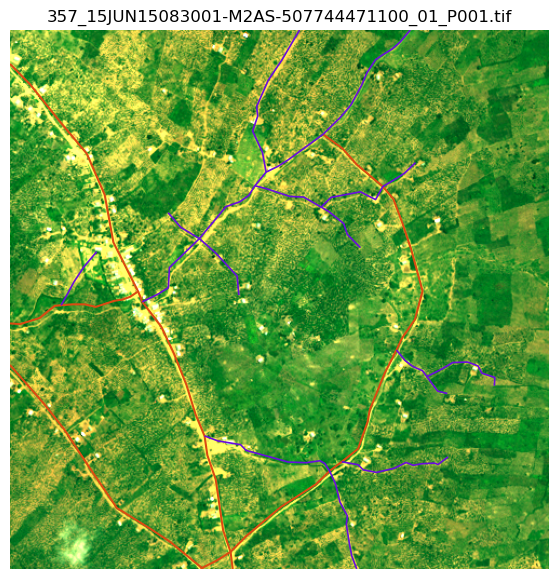

In [12]:
show_chip(ms_chips[2], roads, footpaths)